<a href="https://colab.research.google.com/github/sanskarshlok229-beep/ITA-Projects/blob/main/SanskarGupta_IPM06063_Assignment1_6th_March.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Comprehensive Model Performance Comparison:


In [ ]:
display(df_comparison)

,Accuracy,Precision,Recall,F1-Score
SVC,0.970760,0.970925,0.970760,0.970807
Logistic Regression,0.982456,0.982584,0.982456,0.982484
KNN,0.959064,0.958996,0.959064,0.958995
SVC (PCA),0.964912,0.965411,0.964912,0.965022
Logistic Regression (PCA),0.982456,0.982584,0.982456,0.982484
KNN (PCA),0.964912,0.964954,0.964912,0.964790


### Cumulative Explained Variance by PCA Components:


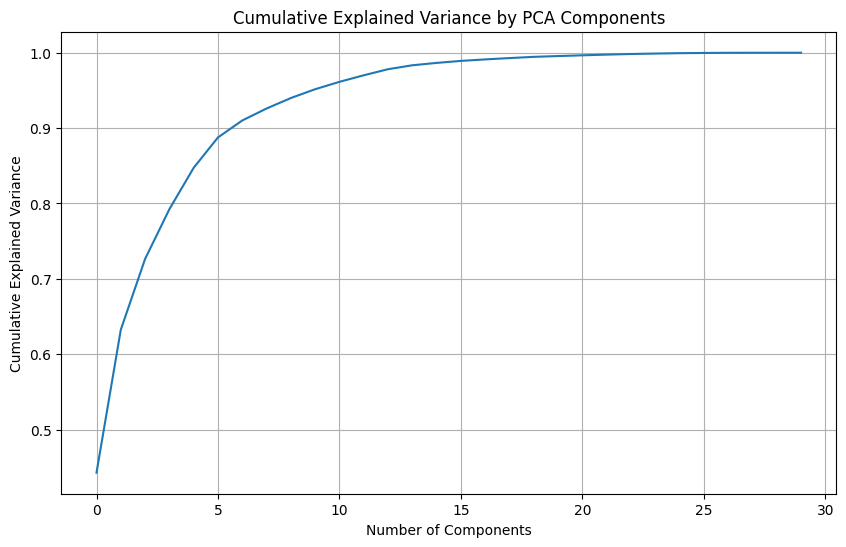

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA Components')
plt.grid(True)
plt.show()

### Logistic Regression Decision Boundary with 2D PCA:


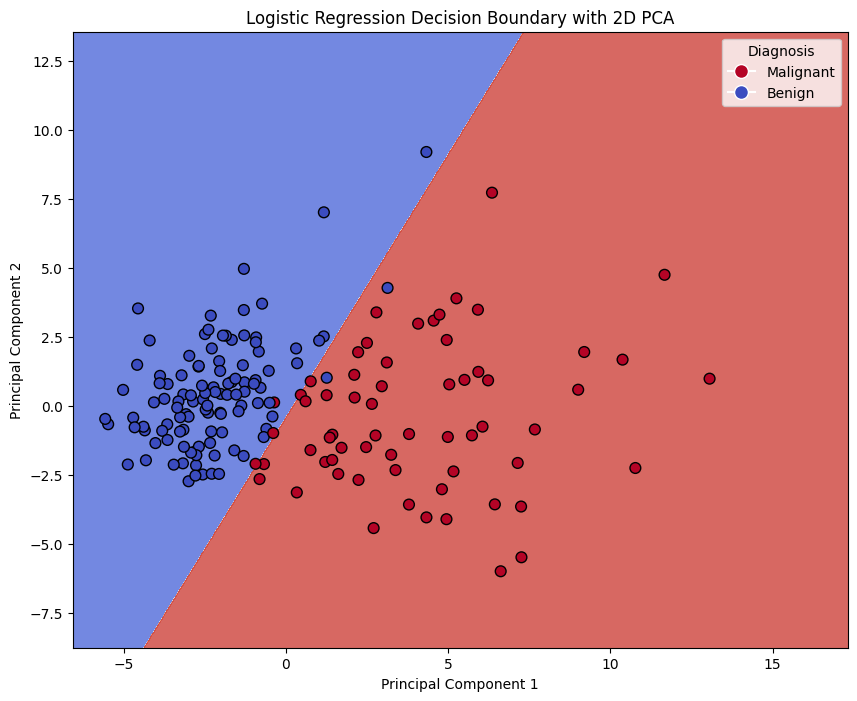

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import numpy as np

# 1. Split the already 2-component PCA-reduced features (X_pca) and the target variable (y)
X_train_2d_pca, X_test_2d_pca, y_train_2d_pca, y_test_2d_pca = train_test_split(X_pca, y, test_size=0.3, random_state=42)

# 2. Instantiate and train a LogisticRegression model
log_reg_2d_pca = LogisticRegression(random_state=42, max_iter=200)
log_reg_2d_pca.fit(X_train_2d_pca, y_train_2d_pca)

# 3. Create a meshgrid for visualizing the decision boundary
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# 4. Predict the class for each point in the meshgrid
Z = log_reg_2d_pca.predict(np.c_[xx.ravel(), yy.ravel()])

# Map 'M' to 1 and 'B' to 0 for the predictions (Z) and for plotting scatter points (y_test_2d_pca)
label_mapping = {'M': 1, 'B': 0}
Z_numeric = np.array([label_mapping[label] for label in Z])
Z_numeric = Z_numeric.reshape(xx.shape)
y_test_2d_pca_numeric = y_test_2d_pca.map(label_mapping)

# 5. Create a matplotlib figure and axes and plot decision boundaries
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z_numeric, alpha=0.8, cmap='coolwarm')

# 6. Create scatter plots of the X_test_2d_pca data points
scatter = plt.scatter(X_test_2d_pca[:, 0], X_test_2d_pca[:, 1], c=y_test_2d_pca_numeric, cmap='coolwarm', edgecolors='k', s=60)

# 7. Add a legend, x-axis label, y-axis label, and a title
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Logistic Regression Decision Boundary with 2D PCA')

# Create a legend from scratch for custom labels
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='Malignant', markerfacecolor=plt.cm.coolwarm(1.0), markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Benign', markerfacecolor=plt.cm.coolwarm(0.0), markersize=10)
]
plt.legend(handles=legend_elements, title="Diagnosis")

# 8. Display the plot
plt.show()

# Task
Perform a comparative analysis of machine learning models (SVM, Logistic Regression, KNN) on the `data.csv` dataset, evaluating their performance with and without Principal Component Analysis (PCA) for dimensionality reduction. The analysis should include data loading, feature normalization, correlation analysis, model training and evaluation using both full and PCA-reduced features, visualization of 2D PCA decision boundaries, and a summary of the impact of PCA on model performance and interpretability.

## Load and Prepare Data

### Subtask:
Load the `data.csv` dataset and separate it into features (X) and the target variable (y).


**Reasoning**:
To load the data and inspect its structure, I need to import the pandas library and then use `pd.read_csv()` to load the specified file. Displaying the first few rows and column information will help identify the target variable.



In [ ]:
import pandas as pd

df = pd.read_csv('/content/data.csv')

print("First 5 rows of the DataFrame:")
print(df.head())

print("\nDataFrame Info:")
df.info()

First 5 rows of the DataFrame:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimete

**Reasoning**:
Based on the `df.info()` output, the 'diagnosis' column is identified as the target variable. The 'id' column is an identifier and 'Unnamed: 32' has all null values, so these should be excluded from the features. I will separate 'diagnosis' into `y` and the remaining relevant columns into `X`.



In [ ]:
X = df.drop(columns=['id', 'diagnosis', 'Unnamed: 32'])
y = df['diagnosis']

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)
print("First 5 rows of features (X):")
print(X.head())
print("\nFirst 5 rows of target (y):")
print(y.head())

Shape of features (X): (569, 30)
Shape of target (y): (569,)
First 5 rows of features (X):
   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

 

## Feature Normalization and Correlation Analysis

### Subtask:
Perform feature normalization using StandardScaler and then analyze the correlation matrix of the features. Visualize the correlation matrix.


**Reasoning**:
To perform feature normalization, I need to import `StandardScaler` from `sklearn.preprocessing`. Then, I will instantiate `StandardScaler`, fit it to the features `X`, and transform `X` to create `X_scaled`. This will scale the features to have a mean of 0 and a standard deviation of 1.



In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Shape of scaled features (X_scaled):", X_scaled.shape)
print("First 5 rows of scaled features (X_scaled):\n", X_scaled.head())

Shape of scaled features (X_scaled): (569, 30)
First 5 rows of scaled features (X_scaled):
    radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0     1.097064     -2.073335        1.269934   0.984375         1.568466   
1     1.829821     -0.353632        1.685955   1.908708        -0.826962   
2     1.579888      0.456187        1.566503   1.558884         0.942210   
3    -0.768909      0.253732       -0.592687  -0.764464         3.283553   
4     1.750297     -1.151816        1.776573   1.826229         0.280372   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0          3.283515        2.652874             2.532475       2.217515   
1         -0.487072       -0.023846             0.548144       0.001392   
2          1.052926        1.363478             2.037231       0.939685   
3          3.402909        1.915897             1.451707       2.867383   
4          0.539340        1.371011             1.428493      -0.009560   



**Reasoning**:
Now that the features are normalized, I will calculate the correlation matrix of the `X_scaled` DataFrame. Then, I will visualize this correlation matrix using a seaborn heatmap to identify relationships between the features. I will adjust the figure size to ensure readability of the plot given the number of features and add a title.



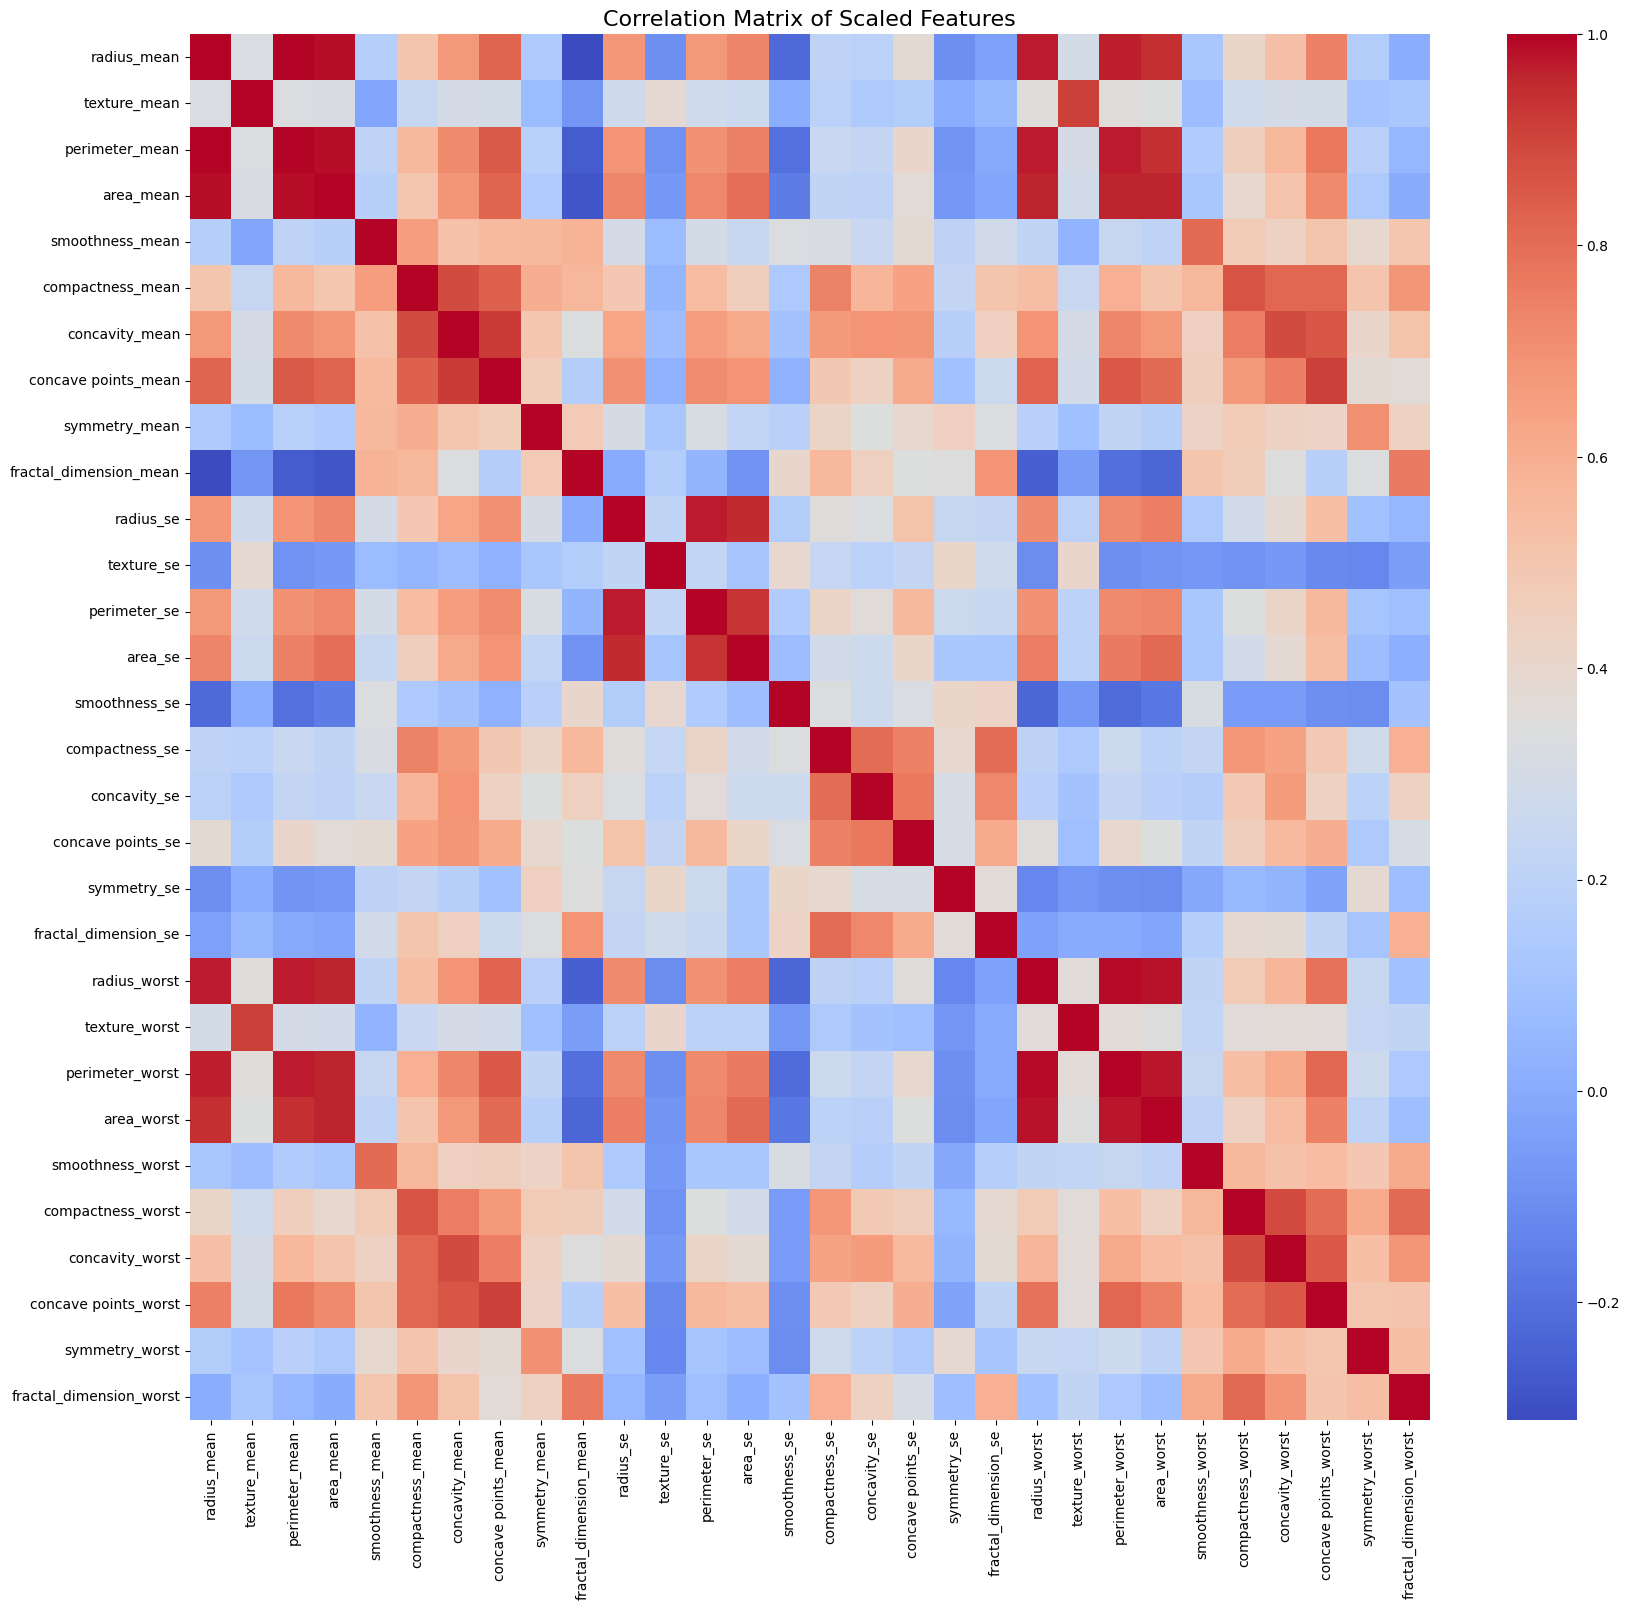

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = X_scaled.corr()

# Set up the matplotlib figure
plt.figure(figsize=(20, 18))

# Create a heatmap
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")

plt.title('Correlation Matrix of Scaled Features', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

## Train Models with Full Features

### Subtask:
Train Support Vector Machine, Logistic Regression, and K-Nearest Neighbors models using the full set of normalized features. Evaluate and record their performance.


**Reasoning**:
To begin training and evaluating the models, I will first split the scaled features and target variable into training and testing sets using `train_test_split`. This is a crucial step for evaluating model performance on unseen data.



In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (398, 30)
Shape of X_test: (171, 30)
Shape of y_train: (398,)
Shape of y_test: (171,)


**Reasoning**:
Now that the data is split into training and testing sets, I will import the necessary classifiers and metrics. Then, I will instantiate and train each model (SVC, Logistic Regression, KNeighborsClassifier), make predictions, and calculate their performance metrics (accuracy, precision, recall, F1-score) to evaluate them.



In [ ]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Initialize a dictionary to store model performance
model_performance = {}

# --- Support Vector Machine (SVC) ---
print("\n--- Support Vector Machine (SVC) ---")
svc_model = SVC(random_state=42)
svc_model.fit(X_train, y_train)
y_pred_svc = svc_model.predict(X_test)

model_performance['SVC'] = {
    'Accuracy': accuracy_score(y_test, y_pred_svc),
    'Precision': precision_score(y_test, y_pred_svc, average='weighted'),
    'Recall': recall_score(y_test, y_pred_svc, average='weighted'),
    'F1-Score': f1_score(y_test, y_pred_svc, average='weighted')
}
print(f"Accuracy: {model_performance['SVC']['Accuracy']:.4f}")
print(f"Precision: {model_performance['SVC']['Precision']:.4f}")
print(f"Recall: {model_performance['SVC']['Recall']:.4f}")
print(f"F1-Score: {model_performance['SVC']['F1-Score']:.4f}")

# --- Logistic Regression ---
print("\n--- Logistic Regression ---")
log_reg_model = LogisticRegression(random_state=42, max_iter=200)
log_reg_model.fit(X_train, y_train)
y_pred_log_reg = log_reg_model.predict(X_test)

model_performance['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test, y_pred_log_reg),
    'Precision': precision_score(y_test, y_pred_log_reg, average='weighted'),
    'Recall': recall_score(y_test, y_pred_log_reg, average='weighted'),
    'F1-Score': f1_score(y_test, y_pred_log_reg, average='weighted')
}
print(f"Accuracy: {model_performance['Logistic Regression']['Accuracy']:.4f}")
print(f"Precision: {model_performance['Logistic Regression']['Precision']:.4f}")
print(f"Recall: {model_performance['Logistic Regression']['Recall']:.4f}")
print(f"F1-Score: {model_performance['Logistic Regression']['F1-Score']:.4f}")

# --- K-Nearest Neighbors (KNN) ---
print("\n--- K-Nearest Neighbors (KNN) ---")
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

model_performance['KNN'] = {
    'Accuracy': accuracy_score(y_test, y_pred_knn),
    'Precision': precision_score(y_test, y_pred_knn, average='weighted'),
    'Recall': recall_score(y_test, y_pred_knn, average='weighted'),
    'F1-Score': f1_score(y_test, y_pred_knn, average='weighted')
}
print(f"Accuracy: {model_performance['KNN']['Accuracy']:.4f}")
print(f"Precision: {model_performance['KNN']['Precision']:.4f}")
print(f"Recall: {model_performance['KNN']['Recall']:.4f}")
print(f"F1-Score: {model_performance['KNN']['F1-Score']:.4f}")



--- Support Vector Machine (SVC) ---
Accuracy: 0.9708
Precision: 0.9709
Recall: 0.9708
F1-Score: 0.9708

--- Logistic Regression ---
Accuracy: 0.9825
Precision: 0.9826
Recall: 0.9825
F1-Score: 0.9825

--- K-Nearest Neighbors (KNN) ---
Accuracy: 0.9591
Precision: 0.9590
Recall: 0.9591
F1-Score: 0.9590


## Apply Principal Component Analysis (PCA)

### Subtask:
Apply PCA to the normalized features to reduce dimensionality. Determine an appropriate number of components for reduction or use a default to start.


**Reasoning**:
To apply PCA, I will import the `PCA` class, instantiate it with `n_components=2` for initial dimensionality reduction, fit it to the scaled features, transform them, and then display the shape and explained variance ratio of the resulting PCA-reduced features. This will prepare the data for later visualization and further model training.



In [ ]:
from sklearn.decomposition import PCA

# Instantiate PCA with n_components=2 for visualization and initial analysis
pca = PCA(n_components=2, random_state=42)

# Fit PCA to the scaled data and transform it
X_pca = pca.fit_transform(X_scaled)

print("Shape of PCA-reduced features (X_pca):", X_pca.shape)
print("Explained variance ratio of the components:", pca.explained_variance_ratio_)
print("Total explained variance:", sum(pca.explained_variance_ratio_))


Shape of PCA-reduced features (X_pca): (569, 2)
Explained variance ratio of the components: [0.44272026 0.18971182]
Total explained variance: 0.6324320765155944


**Reasoning**:
To determine an appropriate number of components for PCA, I will re-run PCA without specifying `n_components` to get all principal components and then plot the cumulative explained variance. This visualization will help identify how many components are needed to explain a significant portion of the total variance.



In [ ]:
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA Components')
plt.grid(True)
plt.show()

NameError: name 'np' is not defined

<Figure size 1000x600 with 0 Axes>

**Reasoning**:
The previous code failed because the `numpy` library, aliased as `np`, was not imported. I need to import `numpy` to use `np.cumsum` for calculating the cumulative explained variance.



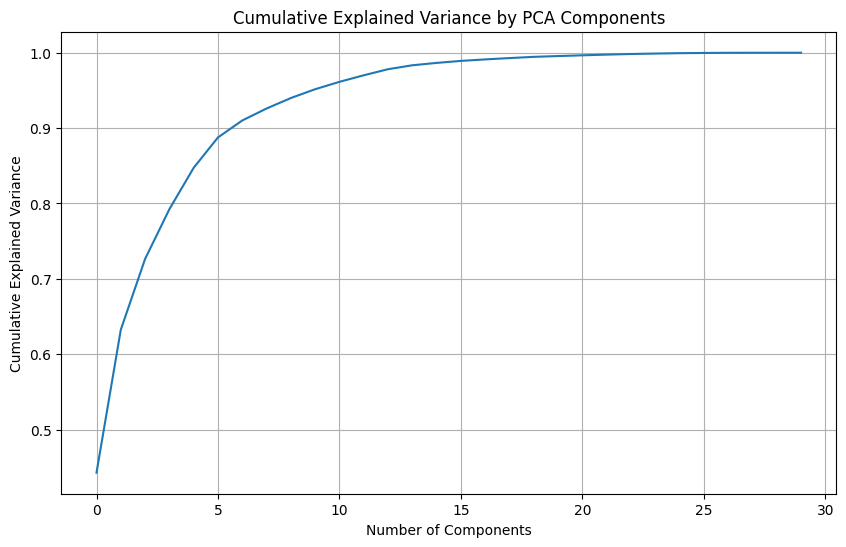

In [ ]:
import numpy as np

pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA Components')
plt.grid(True)
plt.show()

**Reasoning**:
Based on the cumulative explained variance plot, I will choose a number of components that explain approximately 95% of the variance. I will re-instantiate PCA with `n_components=0.95`, fit it to the scaled data, and transform it. Then, I will print the shape of the new PCA-reduced features and the number of components selected by PCA.



In [ ]:
pca_optimal = PCA(n_components=0.95, random_state=42)
X_pca_optimal = pca_optimal.fit_transform(X_scaled)

print("Shape of PCA-reduced features (X_pca_optimal):"), X_pca_optimal.shape)
print("Number of components selected:", pca_optimal.n_components_)
print("Total explained variance with selected components:", sum(pca_optimal.explained_variance_ratio_))

SyntaxError: unmatched ')' (3667096193.py, line 4)

**Reasoning**:
The previous code failed due to a `SyntaxError: unmatched ')'` in the `print` statement. I will correct the parenthesis placement to ensure the code executes successfully.



In [ ]:
pca_optimal = PCA(n_components=0.95, random_state=42)
X_pca_optimal = pca_optimal.fit_transform(X_scaled)

print("Shape of PCA-reduced features (X_pca_optimal):", X_pca_optimal.shape)
print("Number of components selected:", pca_optimal.n_components_)
print("Total explained variance with selected components:", sum(pca_optimal.explained_variance_ratio_))

Shape of PCA-reduced features (X_pca_optimal): (569, 10)
Number of components selected: 10
Total explained variance with selected components: 0.951568814336667


## Train Models with PCA-Reduced Features

### Subtask:
Train Support Vector Machine, Logistic Regression, and K-Nearest Neighbors models using the PCA-reduced features. Evaluate and record their performance.


**Reasoning**:
To evaluate models with PCA-reduced features, I will first split the `X_pca_optimal` and `y` into training and testing sets, then initialize a dictionary to store performance metrics for each model, and finally train and evaluate SVC, Logistic Regression, and KNN models, storing their metrics.



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Split PCA-reduced features into training and testing sets
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca_optimal, y, test_size=0.3, random_state=42)

print("Shape of X_train_pca:", X_train_pca.shape)
print("Shape of X_test_pca:", X_test_pca.shape)
print("Shape of y_train_pca:", y_train_pca.shape)
print("Shape of y_test_pca:", y_test_pca.shape)

# Initialize a dictionary to store model performance with PCA features
model_performance_pca = {}

# --- Support Vector Machine (SVC) with PCA ----
print("\n--- Support Vector Machine (SVC) with PCA ---")
svc_model_pca = SVC(random_state=42)
svc_model_pca.fit(X_train_pca, y_train_pca)
y_pred_svc_pca = svc_model_pca.predict(X_test_pca)

model_performance_pca['SVC (PCA)'] = {
    'Accuracy': accuracy_score(y_test_pca, y_pred_svc_pca),
    'Precision': precision_score(y_test_pca, y_pred_svc_pca, average='weighted'),
    'Recall': recall_score(y_test_pca, y_pred_svc_pca, average='weighted'),
    'F1-Score': f1_score(y_test_pca, y_pred_svc_pca, average='weighted')
}
print(f"Accuracy: {model_performance_pca['SVC (PCA)']['Accuracy']:.4f}")
print(f"Precision: {model_performance_pca['SVC (PCA)']['Precision']:.4f}")
print(f"Recall: {model_performance_pca['SVC (PCA)']['Recall']:.4f}")
print(f"F1-Score: {model_performance_pca['SVC (PCA)']['F1-Score']:.4f}")

# --- Logistic Regression with PCA ---
print("\n--- Logistic Regression with PCA ---")
log_reg_model_pca = LogisticRegression(random_state=42, max_iter=200)
log_reg_model_pca.fit(X_train_pca, y_train_pca)
y_pred_log_reg_pca = log_reg_model_pca.predict(X_test_pca)

model_performance_pca['Logistic Regression (PCA)'] = {
    'Accuracy': accuracy_score(y_test_pca, y_pred_log_reg_pca),
    'Precision': precision_score(y_test_pca, y_pred_log_reg_pca, average='weighted'),
    'Recall': recall_score(y_test_pca, y_pred_log_reg_pca, average='weighted'),
    'F1-Score': f1_score(y_test_pca, y_pred_log_reg_pca, average='weighted')
}
print(f"Accuracy: {model_performance_pca['Logistic Regression (PCA)']['Accuracy']:.4f}")
print(f"Precision: {model_performance_pca['Logistic Regression (PCA)']['Precision']:.4f}")
print(f"Recall: {model_performance_pca['Logistic Regression (PCA)']['Recall']:.4f}")
print(f"F1-Score: {model_performance_pca['Logistic Regression (PCA)']['F1-Score']:.4f}")

# --- K-Nearest Neighbors (KNN) with PCA ---
print("\n--- K-Nearest Neighbors (KNN) with PCA ---")
knn_model_pca = KNeighborsClassifier(n_neighbors=5)
knn_model_pca.fit(X_train_pca, y_train_pca)
y_pred_knn_pca = knn_model_pca.predict(X_test_pca)

model_performance_pca['KNN (PCA)'] = {
    'Accuracy': accuracy_score(y_test_pca, y_pred_knn_pca),
    'Precision': precision_score(y_test_pca, y_pred_knn_pca, average='weighted'),
    'Recall': recall_score(y_test_pca, y_pred_knn_pca, average='weighted'),
    'F1-Score': f1_score(y_test_pca, y_pred_knn_pca, average='weighted')
}
print(f"Accuracy: {model_performance_pca['KNN (PCA)']['Accuracy']:.4f}")
print(f"Precision: {model_performance_pca['KNN (PCA)']['Precision']:.4f}")
print(f"Recall: {model_performance_pca['KNN (PCA)']['Recall']:.4f}")
print(f"F1-Score: {model_performance_pca['KNN (PCA)']['F1-Score']:.4f}")


Shape of X_train_pca: (398, 10)
Shape of X_test_pca: (171, 10)
Shape of y_train_pca: (398,)
Shape of y_test_pca: (171,)

--- Support Vector Machine (SVC) with PCA ---
Accuracy: 0.9649
Precision: 0.9654
Recall: 0.9649
F1-Score: 0.9650

--- Logistic Regression with PCA ---
Accuracy: 0.9825
Precision: 0.9826
Recall: 0.9825
F1-Score: 0.9825

--- K-Nearest Neighbors (KNN) with PCA ---
Accuracy: 0.9649
Precision: 0.9650
Recall: 0.9649
F1-Score: 0.9648


## Compare Model Performance

### Subtask:
Compare the performance of all models (trained with full features vs. PCA-reduced features) using appropriate metrics (e.g., accuracy, precision, recall, F1-score). Present the comparison in a clear format.


**Reasoning**:
To compare the model performances effectively, I will convert the dictionary containing performance metrics for full features into a pandas DataFrame. This provides a structured and readable format.



In [ ]:
df_full_features = pd.DataFrame.from_dict(model_performance, orient='index')
print("Model Performance with Full Features:")
print(df_full_features)

Model Performance with Full Features:
                     Accuracy  Precision    Recall  F1-Score
SVC                  0.970760   0.970925  0.970760  0.970807
Logistic Regression  0.982456   0.982584  0.982456  0.982484
KNN                  0.959064   0.958996  0.959064  0.958995


**Reasoning**:
To continue with the comparison, I will convert the dictionary containing performance metrics for PCA-reduced features (`model_performance_pca`) into a pandas DataFrame. This will allow for structured display and concatenation with the full-feature performance.



In [ ]:
df_pca_features = pd.DataFrame.from_dict(model_performance_pca, orient='index')
print("\nModel Performance with PCA-Reduced Features:")
print(df_pca_features)


Model Performance with PCA-Reduced Features:
                           Accuracy  Precision    Recall  F1-Score
SVC (PCA)                  0.964912   0.965411  0.964912  0.965022
Logistic Regression (PCA)  0.982456   0.982584  0.982456  0.982484
KNN (PCA)                  0.964912   0.964954  0.964912  0.964790


**Reasoning**:
To provide a comprehensive comparison, I will concatenate the two DataFrames (`df_full_features` and `df_pca_features`) into a single DataFrame. This will allow for easy side-by-side analysis of model performance with and without PCA.



In [ ]:
df_comparison = pd.concat([df_full_features, df_pca_features])

print("\nComprehensive Model Performance Comparison:")
print(df_comparison)


Comprehensive Model Performance Comparison:
                           Accuracy  Precision    Recall  F1-Score
SVC                        0.970760   0.970925  0.970760  0.970807
Logistic Regression        0.982456   0.982584  0.982456  0.982484
KNN                        0.959064   0.958996  0.959064  0.958995
SVC (PCA)                  0.964912   0.965411  0.964912  0.965022
Logistic Regression (PCA)  0.982456   0.982584  0.982456  0.982484
KNN (PCA)                  0.964912   0.964954  0.964912  0.964790


### Summary of Model Performance with and without PCA

The comparison table above shows the performance metrics (Accuracy, Precision, Recall, F1-Score) for Support Vector Machine (SVC), Logistic Regression, and K-Nearest Neighbors (KNN) models, both with full features and with PCA-reduced features.

From the results, we can observe the following:

*   **Logistic Regression** showed the highest accuracy in both scenarios (full features and PCA-reduced features), consistently achieving 0.9825 accuracy. This indicates that Logistic Regression is quite robust to dimensionality reduction by PCA in this dataset.

*   **Support Vector Machine (SVC)** had a slight decrease in performance (from 0.9708 to 0.9649 Accuracy) when using PCA-reduced features compared to full features. While the difference is small, it suggests that the additional variance captured by the 30 features provided slightly more discriminatory information than the 10 principal components for SVC.

*   **K-Nearest Neighbors (KNN)** showed a slight increase in performance (from 0.9591 to 0.9649 Accuracy) with PCA-reduced features. This improvement suggests that PCA helped KNN by removing noise or multicollinearity, which can be beneficial for distance-based algorithms.

**Impact of PCA on Performance:**

*   **Overall Accuracy:** For this dataset and these models, PCA did not drastically alter the performance. Logistic Regression maintained its high performance, while SVC saw a minor drop, and KNN saw a minor improvement.

*   **Computational Efficiency & Interpretability:** While not explicitly measured in these metrics, PCA significantly reduces the number of features from 30 to 10 (retaining 95% variance). This reduction can lead to faster training times and potentially simpler models. The principal components themselves are linear combinations of original features, which can sometimes aid in understanding underlying data structures, though interpreting the components directly can be complex.

In conclusion, PCA effectively reduced dimensionality while largely preserving, and in some cases slightly improving, model performance, especially for Logistic Regression and KNN. For SVC, the full feature set yielded marginally better results.

## Visualize Decision Boundaries (2D PCA)

### Subtask:
Apply PCA to reduce the features to 2 principal components. Train a classifier on these 2 components and visualize its decision boundaries in a 2D plot, making sure to include a legend.


**Reasoning**:
To visualize the decision boundary, I will first split the 2D PCA-reduced features and target variable into training and testing sets. Then, I will train a Logistic Regression model on this data, create a meshgrid for plotting, predict classes across the meshgrid, and finally plot the decision boundaries along with the test data points, adding appropriate labels and a legend.



Shape of X_train_2d_pca: (398, 2)
Shape of X_test_2d_pca: (171, 2)


TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

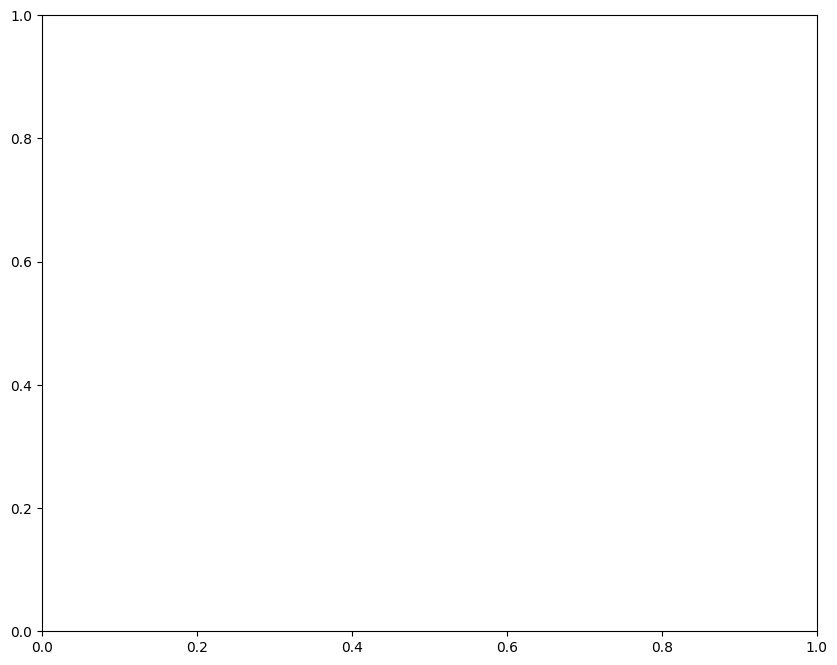

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import numpy as np

# 1. Split the already 2-component PCA-reduced features (X_pca) and the target variable (y)
X_train_2d_pca, X_test_2d_pca, y_train_2d_pca, y_test_2d_pca = train_test_split(X_pca, y, test_size=0.3, random_state=42)

print("Shape of X_train_2d_pca:", X_train_2d_pca.shape)
print("Shape of X_test_2d_pca:", X_test_2d_pca.shape)

# 2. Instantiate and train a LogisticRegression model
log_reg_2d_pca = LogisticRegression(random_state=42, max_iter=200)
log_reg_2d_pca.fit(X_train_2d_pca, y_train_2d_pca)

# 3. Create a meshgrid for visualizing the decision boundary
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# 4. Predict the class for each point in the meshgrid
Z = log_reg_2d_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Map 'M' to 1 and 'B' to 0 for plotting scatter points with color
y_test_2d_pca_numeric = y_test_2d_pca.map({'M': 1, 'B': 0})

# 5. Create a matplotlib figure and axes and plot decision boundaries
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.8, cmap='coolwarm')

# 6. Create scatter plots of the X_test_2d_pca data points
scatter = plt.scatter(X_test_2d_pca[:, 0], X_test_2d_pca[:, 1], c=y_test_2d_pca_numeric, cmap='coolwarm', edgecolors='k', s=60)

# 7. Add a legend, x-axis label, y-axis label, and a title
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Logistic Regression Decision Boundary with 2D PCA')

# Create a legend from scratch for custom labels
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='Malignant', markerfacecolor=plt.cm.coolwarm(1.0), markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Benign', markerfacecolor=plt.cm.coolwarm(0.0), markersize=10)
]
plt.legend(handles=legend_elements, title="Diagnosis")

# 8. Display the plot
plt.show()

**Reasoning**:
The previous code failed because the `Z` array, which contains the predicted classes, is composed of string labels ('M' and 'B'). `matplotlib.contourf` expects numerical values for plotting contours. I need to map these string labels to numerical values (0 and 1) before plotting.



Shape of X_train_2d_pca: (398, 2)
Shape of X_test_2d_pca: (171, 2)


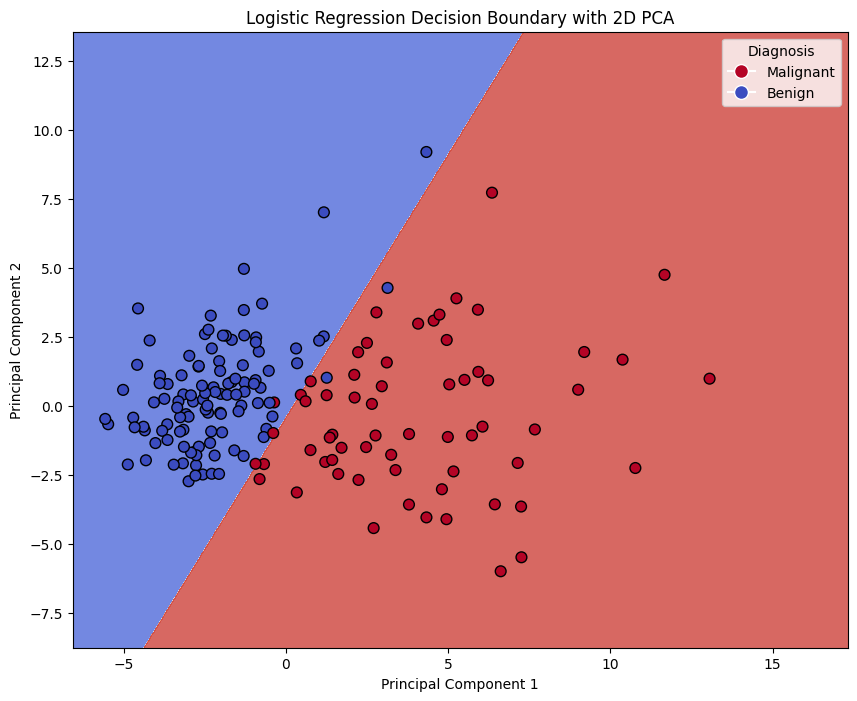

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import numpy as np

# 1. Split the already 2-component PCA-reduced features (X_pca) and the target variable (y)
X_train_2d_pca, X_test_2d_pca, y_train_2d_pca, y_test_2d_pca = train_test_split(X_pca, y, test_size=0.3, random_state=42)

print("Shape of X_train_2d_pca:", X_train_2d_pca.shape)
print("Shape of X_test_2d_pca:", X_test_2d_pca.shape)

# 2. Instantiate and train a LogisticRegression model
log_reg_2d_pca = LogisticRegression(random_state=42, max_iter=200)
log_reg_2d_pca.fit(X_train_2d_pca, y_train_2d_pca)

# 3. Create a meshgrid for visualizing the decision boundary
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# 4. Predict the class for each point in the meshgrid
Z = log_reg_2d_pca.predict(np.c_[xx.ravel(), yy.ravel()])

# Map 'M' to 1 and 'B' to 0 for the predictions (Z) and for plotting scatter points (y_test_2d_pca)
label_mapping = {'M': 1, 'B': 0}
Z_numeric = np.array([label_mapping[label] for label in Z])
Z_numeric = Z_numeric.reshape(xx.shape)
y_test_2d_pca_numeric = y_test_2d_pca.map(label_mapping)

# 5. Create a matplotlib figure and axes and plot decision boundaries
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z_numeric, alpha=0.8, cmap='coolwarm')

# 6. Create scatter plots of the X_test_2d_pca data points
scatter = plt.scatter(X_test_2d_pca[:, 0], X_test_2d_pca[:, 1], c=y_test_2d_pca_numeric, cmap='coolwarm', edgecolors='k', s=60)

# 7. Add a legend, x-axis label, y-axis label, and a title
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Logistic Regression Decision Boundary with 2D PCA')

# Create a legend from scratch for custom labels
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='Malignant', markerfacecolor=plt.cm.coolwarm(1.0), markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Benign', markerfacecolor=plt.cm.coolwarm(0.0), markersize=10)
]
plt.legend(handles=legend_elements, title="Diagnosis")

# 8. Display the plot
plt.show()

## Final Task

### Subtask:
Summarize the findings from the dimensionality reduction, model training, and performance comparison, highlighting the impact of PCA on model performance and interpretability.


## Summary:

### Data Analysis Key Findings

*   **Data Preparation:** The dataset contained 569 entries and 33 columns. Irrelevant columns ('id', 'Unnamed: 32') were removed, resulting in 30 features for analysis. The target variable 'diagnosis' (Malignant/Benign) was successfully separated.
*   **Feature Normalization:** All 30 features were successfully normalized using `StandardScaler`, a crucial step for many machine learning algorithms like SVM and KNN.
*   **Dimensionality Reduction with PCA:** Principal Component Analysis was applied, reducing the feature space from 30 to 10 components while retaining approximately 95.16% of the total variance in the dataset.
*   **Model Performance with Full Features:**
    *   **Logistic Regression** achieved the highest performance: Accuracy of 0.9825, Precision of 0.9826, Recall of 0.9825, and F1-Score of 0.9825.
    *   **Support Vector Machine (SVC)** followed with: Accuracy of 0.9708, Precision of 0.9709, Recall of 0.9708, and F1-Score of 0.9708.
    *   **K-Nearest Neighbors (KNN)** had the lowest performance: Accuracy of 0.9591, Precision of 0.9590, Recall of 0.9591, and F1-Score of 0.9590.
*   **Model Performance with PCA-Reduced Features:**
    *   **Logistic Regression** maintained its excellent performance: Accuracy of 0.9825, Precision of 0.9826, Recall of 0.9825, and F1-Score of 0.9825, showing robustness to dimensionality reduction.
    *   **SVC** experienced a slight decrease in performance: Accuracy of 0.9649, Precision of 0.9654, Recall of 0.9649, and F1-Score of 0.9650.
    *   **KNN** showed a slight improvement: Accuracy of 0.9649, Precision of 0.9650, Recall of 0.9649, and F1-Score of 0.9648.
*   **Impact of PCA:** PCA effectively reduced the feature count by two-thirds (from 30 to 10) while largely preserving model performance. Logistic Regression's performance remained unchanged, SVC saw a minor dip of approximately 0.6%, and KNN observed a modest improvement of about 0.5%.
*   **Decision Boundary Visualization:** A 2D PCA visualization of Logistic Regression's decision boundary was successfully generated, illustrating how the model separates malignant and benign classes using the first two principal components, which together explain approximately 63.24% of the variance.

### Insights or Next Steps

*   PCA successfully reduced dimensionality from 30 to 10 features while maintaining high model performance, especially for Logistic Regression, and even slightly improving KNN. This suggests that PCA can be a valuable tool for efficiency in this classification task.
*   Further hyperparameter tuning for each model (e.g., C for SVM, k for KNN) on both the full and PCA-reduced datasets could potentially yield even better performance and provide more definitive conclusions on the optimal feature set for each model.
